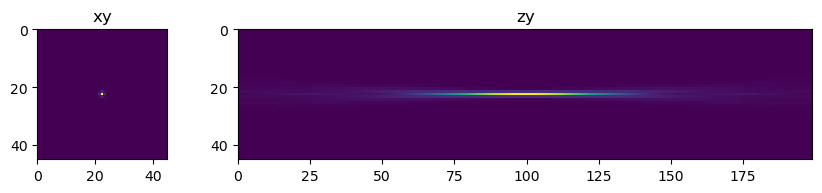

In [37]:
from tnia.deconvolution.psfs import gibson_lanni_3D
from tnia.plotting.projections import show_xy_zy_slice_center
import numpy as np
import matplotlib.pyplot as plt

xy_psf_dim = 45
NA = 1.4
x_voxel_size = 0.185
z_voxel_size = 0.01
z_psf_dim = 199
wl = .500
ni = 1.5
ns = 1.4
defocus = 0

psf = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wl, use_psfm=True)
psf = np.squeeze(psf.astype('float32'))

from tnia.plotting.projections import show_xy_zy_slice_center

fig = show_xy_zy_slice_center(psf)




point (0,0): z=99, y=12, x=12
point (0,1): z=0, y=12, x=38
point (0,2): z=99, y=12, x=64
point (0,3): z=198, y=12, x=90
point (0,4): z=99, y=12, x=116
point (1,0): z=99, y=38, x=12
point (1,1): z=0, y=38, x=38
point (1,2): z=99, y=38, x=64
point (1,3): z=198, y=38, x=90
point (1,4): z=99, y=38, x=116
point (2,0): z=99, y=64, x=12
point (2,1): z=0, y=64, x=38
point (2,2): z=99, y=64, x=64
point (2,3): z=198, y=64, x=90
point (2,4): z=99, y=64, x=116
point (3,0): z=99, y=90, x=12
point (3,1): z=0, y=90, x=38
point (3,2): z=99, y=90, x=64
point (3,3): z=198, y=90, x=90
point (3,4): z=99, y=90, x=116
point (4,0): z=99, y=116, x=12
point (4,1): z=0, y=116, x=38
point (4,2): z=99, y=116, x=64
point (4,3): z=198, y=116, x=90
point (4,4): z=99, y=116, x=116


Text(0.5, 0.98, '5x5 grid phantom, columns at different z')

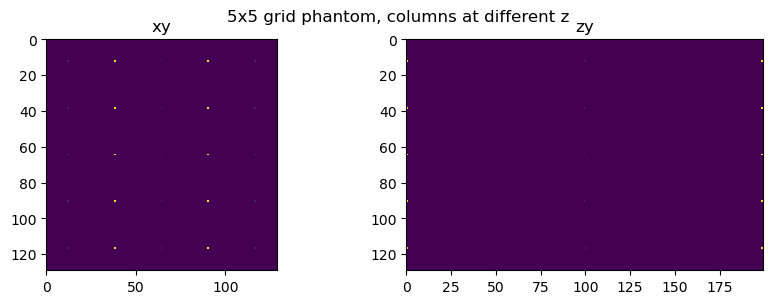

In [73]:
from tnia.plotting.projections import show_xy_zy_max

phantom = np.zeros((199, 129, 129), dtype=np.float32)

# 5x5 grid in xy, each column at a different z focus
z_center = 199 // 2
z_offsets = [0, -100, 0, 100, 0] #np.linspace(-40, 40, 5).astype(int)
intensities = [10000, 100000, 10000, 100000, 10000]

for iy in range(5):
    for ix in range(5):
        y = int(129 * (iy + 0.5) / 5)
        x = int(129 * (ix + 0.5) / 5)
        z = z_center + z_offsets[ix]
        z = np.clip(z, 0, 198)
        y = np.clip(y, 0, 128)
        x = np.clip(x, 0, 128)
        phantom[z, y, x] = intensities[ix]
        print(f'point ({iy},{ix}): z={z}, y={y}, x={x}')

fig = show_xy_zy_max(phantom)
fig.suptitle('5x5 grid phantom, columns at different z')

In [74]:
from tnia.deconvolution.forward import forward 

image = forward(phantom, psf, 2, add_poisson=True, gpu=False)
image[image<0]=0

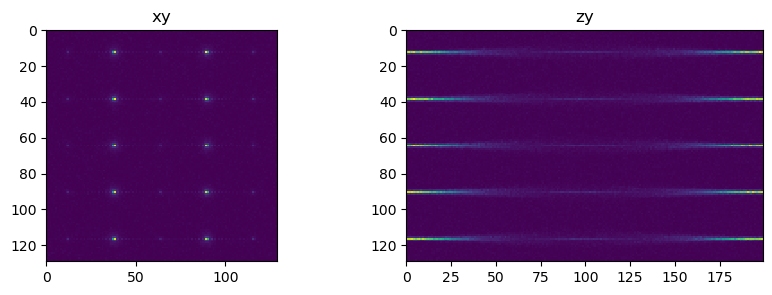

In [75]:
fig = show_xy_zy_max(image)

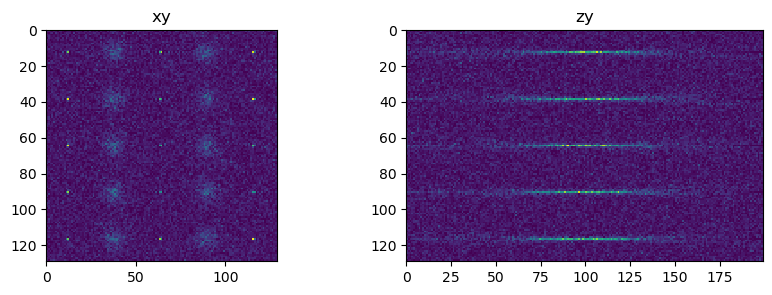

In [76]:
fig = show_xy_zy_slice_center(image)

In [85]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp

input_slice = image[image.shape[0]//2, :, :]

deconvolved_2d = richardson_lucy_cp(input_slice, psf[psf.shape[0]//2], 100)
# add trivial dimension
input_slice = input_slice[np.newaxis, :, :]
deconvolved = richardson_lucy_cp(input_slice, psf, 100, noncirc=True, do_unpad=True)

deconvolved[deconvolved<0]=0


0 10 20 30 40 50 60 70 80 90 

0 10 20 30 40 50 60 70 80 90 


In [78]:
image.shape
image.min(), image.max()

(0, 285)

In [79]:
import napari

viewer = napari.Viewer()
viewer.add_image(image, name='Simulated widefield image')
viewer.add_image(deconvolved, name='Deconvolved from center slice')

<Image layer 'Deconvolved from center slice' at 0x763ed6106430>

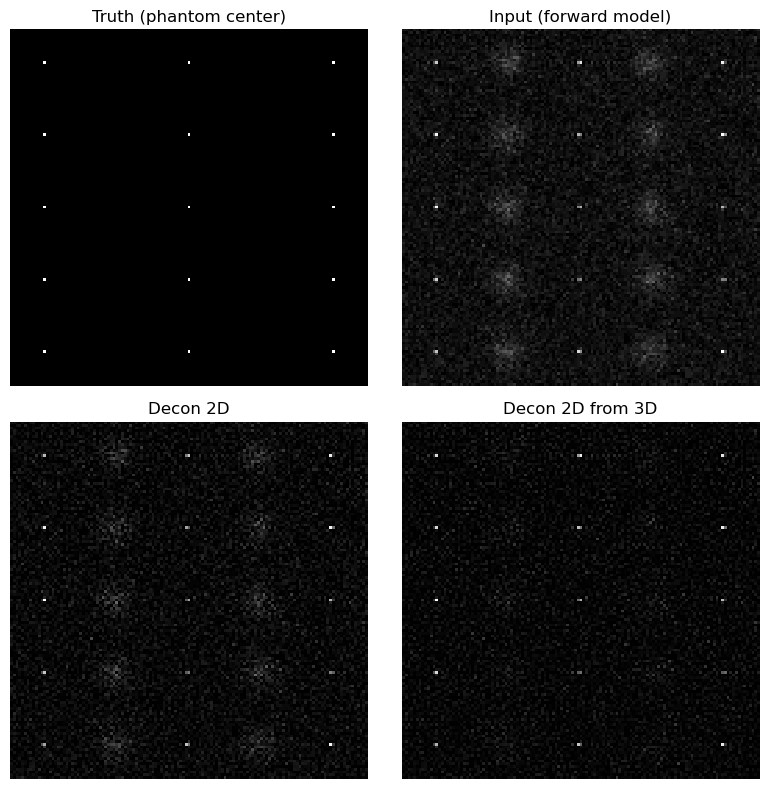

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(phantom[phantom.shape[0]//2], cmap='gray')
axes[0, 0].set_title('Truth (phantom center)')
axes[0, 0].axis('off')
axes[0, 1].imshow(input_slice.squeeze(), cmap='gray')
axes[0, 1].set_title('Input (forward model)')
axes[0, 1].axis('off')
axes[1, 0].imshow(deconvolved_2d.squeeze(), cmap='gray')
axes[1, 0].set_title('Decon 2D')
axes[1, 0].axis('off')
axes[1, 1].imshow(deconvolved[deconvolved.shape[0]//2], cmap='gray')
axes[1, 1].set_title('Decon 2D from 3D')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()